In [1]:
import numpy as np
import jax.numpy as jnp
import dctkit as dt
from dctkit.mesh import util
from dctkit.dec import cochain as C
from dctkit.math.opt import optctrl as oc
import gmsh
import meshio
import tempfile
import os
from functools import partial
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
dt.config()

In [3]:
def generate_sphere_patch_mesh(lc: float, R: float = 1.):
    gmsh.initialize()
    gmsh.model.add("sphere_cap")
    
    # Create points for a 90-degree arc on the XZ plane
    p1 = gmsh.model.occ.addPoint(0, 0, 0, lc) # Center
    p2 = gmsh.model.occ.addPoint(R, 0, 0, lc) # Equator
    p3 = gmsh.model.occ.addPoint(0, 0, R, lc) # North Pole
    
    # Create the arc and revolve it 360 degrees around Z-axis
    arc = gmsh.model.occ.addCircleArc(p2, p1, p3)
    gmsh.model.occ.revolve([(1, arc)], 0, 0, 0, 0, 0, 1, 2*np.pi)
    
    gmsh.model.occ.synchronize()
    gmsh.model.mesh.generate(2)

    with tempfile.NamedTemporaryFile(suffix=".msh", delete=False) as f:
        tmp_path = f.name
    gmsh.write(tmp_path)
    gmsh.finalize()

    mesh = meshio.read(tmp_path)
    os.unlink(tmp_path)
    return mesh, None

In [4]:
# --- Build mesh and simplicial complex ---
lc = 0.1
R = 1.
mesh, _ = generate_sphere_patch_mesh(lc=lc, R=R)
S = util.build_complex_from_mesh(mesh, space_dim=3, is_well_centered=True)
#S.S[0] = np.arange(S.num_nodes).reshape(-1,1)
S.get_hodge_star()
S.get_complex_boundary_faces_indices()


node_coords = S.node_coords  # shape (N, 3)
num_nodes = S.num_nodes

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Circle)
Info    : Done meshing 1D (Wall 0.000342714s, CPU 0.000264s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0635912s, CPU 0.061953s)
Info    : 817 nodes 1649 elements
Info    : Writing '/tmp/tmp3errxr6s.msh'...
Info    : Done writing '/tmp/tmp3errxr6s.msh'



In [5]:
k = 1.

# --- Define exact solution u_true = x^2 + y^2 on the hemisphere ---
# On the unit hemisphere: x^2 + y^2 = 1 - z^2, z in [0, 1]
u_true = np.array(
    node_coords[:, 0]**2 + node_coords[:, 1]**2,
    dtype=dt.float_dtype
)

# --- Identify boundary nodes (equatorial circle, where z ~ 0) ---
# On the hemisphere generated by gmsh with angle3=pi/2, the boundary
# is the equatorial circle at z = 0.
bnodes = S.boundary_simplices[0]
b_values = u_true[bnodes]
boundary_values = (np.array(bnodes, dtype=dt.int_dtype), b_values)

print(f"Num nodes: {num_nodes}, Num boundary nodes: {len(bnodes)}")

# --- Forcing term ---
f_vec = np.array(
    (2. - 6. * node_coords[:, 2]**2).reshape(-1, 1),
    dtype=dt.float_dtype
)
#f_vec = k*C.laplacian(C.CochainP0(S,u_true)).coeffs

# Mask: zero at boundary nodes 
mask = np.ones((num_nodes, 1), dtype=dt.float_dtype)
mask[bnodes, :] = 0.

# --- Initial guess ---
np.random.seed(42)
u_0 = np.random.rand(num_nodes).astype(dt.float_dtype)

# --- Objective: residual of k*Delta u + f = 0, plus boundary penalty ---
gamma = 10000.

Num nodes: 816, Num boundary nodes: 63


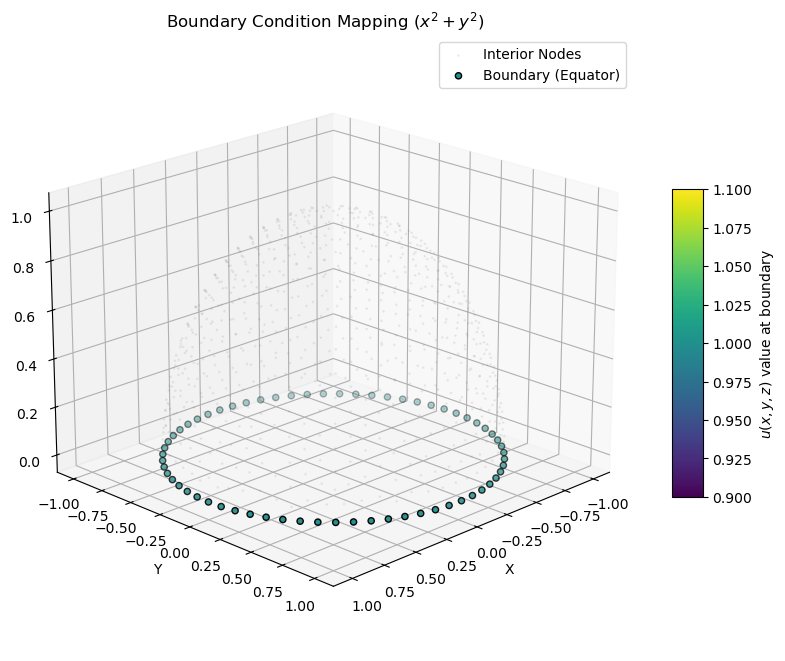

In [6]:
def plot_boundary_conditions(S, bnodes, u_true):
    coords = S.node_coords
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot all nodes (the "ghost" of the hemisphere)
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
               c='gray', alpha=0.1, s=1, label='Interior Nodes')

    # Highlight Boundary Nodes
    b_coords = coords[bnodes]
    b_values = u_true[bnodes]
    
    # We color the boundary based on the Dirichlet value (x^2 + y^2)
    sc = ax.scatter(b_coords[:, 0], b_coords[:, 1], b_coords[:, 2], 
                    c=b_values, cmap='viridis', s=20, edgecolors='black', 
                    label='Boundary (Equator)')

    # Add a colorbar to show the value mapping
    cbar = plt.colorbar(sc, ax=ax, shrink=0.5, aspect=10)
    cbar.set_label('$u(x,y,z)$ value at boundary')

    # Formatting
    ax.set_title("Boundary Condition Mapping ($x^2 + y^2$)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend()
    
    # Set view to see the hemisphere clearly
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_boundary_conditions(S, S.boundary_simplices[0], u_true)

In [7]:
def obj_poisson(x, f, k, boundary_values, gamma, mask):
        pos, value = boundary_values
        c = C.Cochain(0, True, S, x)
        laplacian = C.laplacian(c)
        laplacian.coeffs *= -k
        r = laplacian.coeffs + f
        penalty = jnp.sum((x[pos] - value)**2)
        obj = 0.5 * jnp.linalg.norm(r * mask)**2 + 0.5 * gamma * penalty
        #debug.print("{x}", x= jnp.linalg.norm(r * mask)**2)
        return obj

args = {
    'f': f_vec,
    'k': k,
    'boundary_values': boundary_values,
    'gamma': gamma,
    'mask': mask
}

prb = oc.OptimizationProblem(
    dim=num_nodes, state_dim=num_nodes,
    objfun=obj_poisson, solver_lib="pygmo"
)
prb.set_obj_args(args)
u = prb.solve(x0=u_0, algo="lbfgs",ftol_abs= 1e-12, ftol_rel=1e-12, maxeval=10000)

print(prb.last_opt_result)

# --- Report results ---
print(f"\nSolution dtype: {u.dtype}")
print(f"Max error (all nodes):       {np.max(np.abs(u - u_true)):.4e}")
print(f"Max error (boundary nodes):  {np.max(np.abs(u[bnodes] - u_true[bnodes])):.4e}")
print(f"Mean abs error:              {np.mean(np.abs(u - u_true)):.4e}")

4

Solution dtype: float64
Max error (all nodes):       2.1023e-03
Max error (boundary nodes):  5.6568e-08
Mean abs error:              6.6671e-04


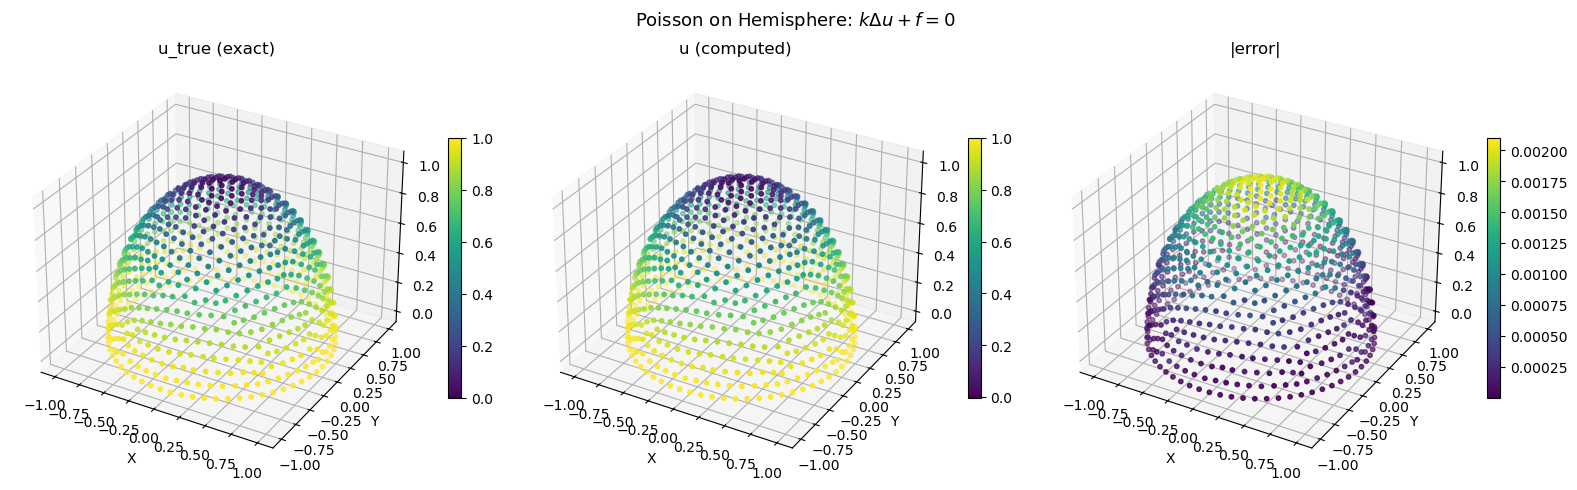

In [8]:
# --- Plot result ---
fig = plt.figure(figsize=(16, 5))

for idx, (values, title) in enumerate(zip(
    [u_true, u, np.abs(u - u_true)],
    ["u_true (exact)", "u (computed)", "|error|"]
)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    sc = ax.scatter(
        node_coords[:, 0], node_coords[:, 1], node_coords[:, 2],
        c=values, cmap='viridis', s=10
    )
    plt.colorbar(sc, ax=ax, shrink=0.6)
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

plt.suptitle("Poisson on Hemisphere: $k\\Delta u + f = 0$", fontsize=13)
plt.tight_layout()
plt.show()